# Can we predict frequency of cannabis usage based on people's demographics, level of education, self-reported impulsivity levels, and gender?

In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz 
from sklearn.model_selection import train_test_split,GridSearchCV,RepeatedStratifiedKFold
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz 

from ucimlrepo import fetch_ucirepo 
  
# Fetching the dataset

drug_consumption = fetch_ucirepo(id=373) 

# Converting the dataset to a pandas dataframe

drugs_df = pd.concat([drug_consumption.data.features, drug_consumption.data.targets], axis=1)

drugs_df.info() # Printing variable types
drugs_df.head() # Printing the first five rows of the dataframe


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1885 non-null   float64
 1   gender     1885 non-null   float64
 2   education  1885 non-null   float64
 3   country    1885 non-null   float64
 4   ethnicity  1885 non-null   float64
 5   nscore     1885 non-null   float64
 6   escore     1885 non-null   float64
 7   oscore     1885 non-null   float64
 8   ascore     1885 non-null   float64
 9   cscore     1885 non-null   float64
 10  impuslive  1885 non-null   float64
 11  ss         1885 non-null   float64
 12  alcohol    1885 non-null   object 
 13  amphet     1885 non-null   object 
 14  amyl       1885 non-null   object 
 15  benzos     1885 non-null   object 
 16  caff       1885 non-null   object 
 17  cannabis   1885 non-null   object 
 18  choc       1885 non-null   object 
 19  coke       1885 non-null   object 
 20  crack   

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,...,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


In [2]:
# Only keeping necessary columns to predict cannabis usage

cannabis_df = drugs_df[['age', 'gender', 'education', 'country', 'ethnicity', 'impuslive', 'cannabis', 'nscore', 'escore', 'oscore', 'ascore', 'cscore', 'ss']]

cannabis_df = cannabis_df.dropna() # Dropping any NA values

cannabis_df.head() # Printing the first five rows of the new dataset

,age,gender,education,country,ethnicity,impuslive,cannabis,nscore,escore,oscore,ascore,cscore,ss
0,0.49788,0.48246,-0.05921,0.96082,0.12600,-0.21712,CL0,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,-1.18084
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.71126,CL4,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.21575
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-1.37983,CL3,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,0.40148
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-1.37983,CL2,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.18084
4,0.49788,0.48246,1.98437,0.96082,-0.31685,-0.21712,CL3,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21575


In [3]:
cannabis_df[["cannabis"]] = OrdinalEncoder().fit_transform(cannabis_df[["cannabis"]]) # Ordinally encoding our target variable

print(cannabis_df['cannabis'].value_counts()) # Checking the statistics of each cannabis usage frequency category


cannabis
6.0    463
0.0    413
2.0    266
3.0    211
1.0    207
5.0    185
4.0    140
Name: count, dtype: int64


In [4]:
cannabis_df['education'].unique()

array([-0.05921,  1.98437,  1.16365, -1.22751, -1.7379 ,  0.45468,
       -0.61113, -2.43591, -1.43719])

In [5]:
cannabis_df['country'] = cannabis_df['country'].replace({
    0.96082:'UK', 
    0.24923:'Canada', 
    -0.57009:'USA',
    -0.28519:'Other', 
    -0.09765:'Australia',
    0.21128:'Republic of Ireland', 
    -0.46841:'New Zealand'})

cannabis_df['education'] = cannabis_df['education'].replace({
    -2.43591:"Left school before 16 years",
    -1.73790:"Left school at 16 years",
    -1.43719:"Left school at 17 years",
    -1.22751:"Left school at 18 years",
    -0.61113:"Some college or university, no certificate or degree",
    -0.05921:"Professional certificate/ diploma",
    0.45468:"University degree",
    1.16365:"Masters degree",
    1.98437:"Doctorate degree"
})

cannabis_df['age'] = cannabis_df['age'].replace({
    -0.95197: "18-24",
    -0.07854: "25-34",
    0.49788: "35-44",
    1.09449: "45-54",
    1.82213: "55-64",
    2.59171: "65+"
})
cannabis_df['gender'] = cannabis_df['gender'].replace({
    0.48246: "Female",
    -0.48246: "Male"
})

cannabis_df['ethnicity'] = cannabis_df['ethnicity'].replace({
    -0.50212: "Asian",
    -1.10702: "Black",
    1.90725: "Mixed-Black/Asian",
    0.12600: "Mixed-White/Asian",
    -0.22166: "Mixed-White/Black",
    0.11440: "Other", 
    -0.31685: "White"
})

In [6]:
# Splitting the data
cat_vars = ['country', 'education', 'age', 'gender', 'ethnicity']

for var in cat_vars:
        dummies = pd.get_dummies(cannabis_df[var], prefix=var) 
        cannabis_df = pd.concat([cannabis_df, dummies], axis=1)

        
cannabis_df= cannabis_df.drop(columns=cat_vars)


X = cannabis_df.drop(columns = 'cannabis') # Defining our feature variables
y = cannabis_df.cannabis # Defining our target variable

if isinstance(y, pd.Series):
    y.loc[y <= 2] = 0
    y.loc[(y > 2) & (y <= 6)] = 1

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.70, stratify= y, random_state = 42)
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50,stratify= y_test, random_state = 30)

/var/folders/17/_8blbkbj1bb5n169js1fsnp40000gn/T/ipykernel_95717/3140184229.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.loc[y <= 2] = 0
/var/folders/17/_8blbkbj1bb5n169js1fsnp40000gn/T/ipykernel_95717/3140184229.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.loc[(y > 2) & (y <= 6)] = 1


In [7]:
# Starting the cross validation process with 10 splits and 5 repeats

kf = RepeatedStratifiedKFold(n_splits = 10, n_repeats = 5, random_state=42)

In [8]:
# Defining our scoring metrics

scoring = {
    'roc_auc': 'roc_auc_ovr',             
    'recall': 'recall_macro',               
    'balanced_accuracy': 'balanced_accuracy'  
}



In [9]:
# Using max_depth as our hyperparameter

param={
    "max_depth" : [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    #"splitter":["best","random"],
    # "min_samples_leaf":[12,3,4,5,6,7,8,9,10],
    # "min_weight_fraction_leaf":[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    #"max_features":["auto","log2","sqrt",None],
    # "max_leaf_nodes":[None,10,20,30,40,50,60,70,80,90], 
    # 'min_impurity_decrease':[0.00005,0.0001,0.0002,0.0005,0.001,0.0015,0.002,0.005,0.01],
    # 'ccp_alpha':[.001,.01,.1]
        }

In [10]:
cl = DecisionTreeClassifier(random_state=1000) # Defining the classifier model

# Searching for the best classifier based on balanced_accuracy

search = GridSearchCV(cl, param, scoring = scoring, n_jobs = -1, cv = kf, refit = 'balanced_accuracy') 

model = search.fit(X_train, y_train) # Fitting the model based on the training data

In [18]:
# Finding the best max_depth

best = model.best_estimator_
print(best)

DecisionTreeClassifier(max_depth=5, random_state=1000)


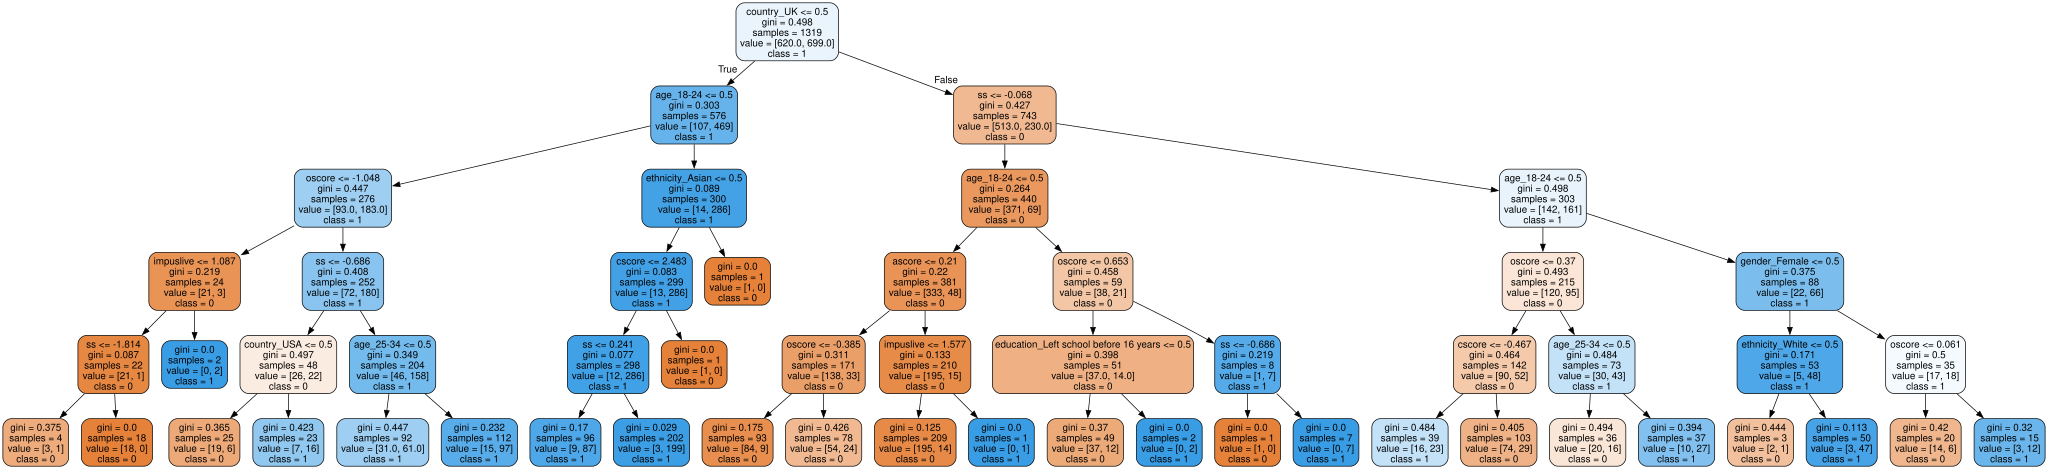

In [19]:
# Printing the decision tree

dot_data = export_graphviz(best, out_file =None,
               feature_names =X.columns,
               filled=True, 
                rounded=True, 
                class_names = ['0', '1'])
               
graph=graphviz.Source(dot_data)
graph

In [20]:
print(model.cv_results_)

{'mean_fit_time': array([0.00287043, 0.00238193, 0.00281281, 0.00366972, 0.00374359,
       0.00409875, 0.00454697, 0.0057175 , 0.0058612 , 0.00576849,
       0.00608472, 0.00564264, 0.00638196, 0.00607225, 0.00554689,
       0.00605676, 0.00611236, 0.0059841 , 0.0058953 , 0.00613183]), 'std_fit_time': array([0.00176443, 0.00098102, 0.0011648 , 0.00142066, 0.00139737,
       0.00149562, 0.00135691, 0.00245306, 0.00288764, 0.00204979,
       0.00219203, 0.00167197, 0.0023651 , 0.00225882, 0.00157621,
       0.00157816, 0.00159906, 0.00181511, 0.00168258, 0.00220913]), 'mean_score_time': array([0.00462159, 0.00310922, 0.00354944, 0.00475886, 0.00366116,
       0.00378531, 0.00377817, 0.00366191, 0.00396586, 0.00423944,
       0.00407248, 0.00355807, 0.00366151, 0.00451402, 0.00412007,
       0.00423937, 0.00322423, 0.00310181, 0.00356953, 0.00349503]), 'std_score_time': array([0.00283527, 0.00110402, 0.00178151, 0.00260772, 0.00169923,
       0.00170204, 0.00224338, 0.00210055, 0.0021732

In [21]:
auc = model.cv_results_['mean_test_roc_auc']
recall= model.cv_results_['mean_test_recall']
bal_acc= model.cv_results_['mean_test_balanced_accuracy']

SDauc = model.cv_results_['std_test_roc_auc']
SDrecall= model.cv_results_['std_test_recall']
SDbal_acc= model.cv_results_['std_test_balanced_accuracy']


for key in param:
    params = str("param_" + key)

depth= np.unique(model.cv_results_[params])

final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc,SDauc,SDrecall,SDbal_acc)),
               columns =['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

final_model

,depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
0,1,0.749186,0.749186,0.749186,0.032189,0.032189,0.032189
1,2,0.833771,0.749733,0.749733,0.032177,0.034475,0.034475
2,3,0.847282,0.778597,0.778597,0.028025,0.027310,0.027310
3,4,0.852028,0.773244,0.773244,0.030689,0.034833,0.034833
4,5,0.842482,0.781523,0.781523,0.036896,0.034969,0.034969
5,6,0.823507,0.766142,0.766142,0.038280,0.039620,0.039620
6,7,0.790699,0.758539,0.758539,0.043401,0.040352,0.040352
7,8,0.767744,0.750367,0.750367,0.045986,0.039683,0.039683
8,9,0.754496,0.748308,0.748308,0.046102,0.037461,0.037461
9,10,0.741031,0.740129,0.740129,0.043305,0.041921,0.041921


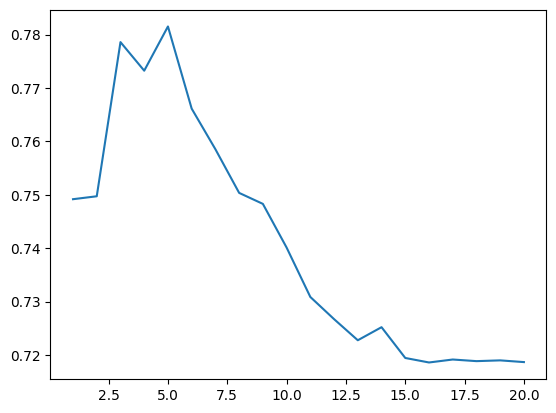

In [15]:
# Finding what depth has the highest balanced accuracy

print(plt.plot(final_model.depth,final_model.bal_acc))

In [16]:
varimp = pd.DataFrame(best.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(varimp)

                                                    importance
country_UK                                            0.485217
ss                                                    0.179308
age_18-24                                             0.121794
oscore                                                0.097038
cscore                                                0.021166
age_25-34                                             0.020944
gender_Female                                         0.018958
impuslive                                             0.014895
country_USA                                           0.014603
ascore                                                0.008176
education_Left school before 16 years                 0.006433
ethnicity_White                                       0.006116
ethnicity_Asian                                       0.005354
country_Republic of Ireland                           0.000000
country_Other                                         0

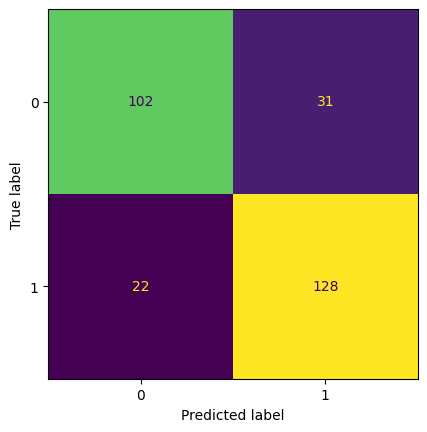

In [17]:
print(ConfusionMatrixDisplay.from_estimator(best, X_tune, y_tune, labels=[0, 1],colorbar=False))